In [21]:
import shutil
from collections import defaultdict

from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, jaccard_score

from ontolearn.owl_neural_reasoner import TripleStoreNeuralReasoner
from ontolearn.knowledge_base import KnowledgeBase
from ontolearn.triple_store import TripleStore
from ontolearn.utils import jaccard_similarity, f1_set_similarity, concept_reducer, concept_reducer_properties
from owlapy.class_expression import (
    OWLClass,
    OWLObjectUnionOf,
    OWLObjectIntersectionOf,
    OWLObjectSomeValuesFrom,
    OWLObjectAllValuesFrom,
    OWLObjectMinCardinality,
    OWLObjectMaxCardinality,
    OWLObjectOneOf,
    OWLObjectComplementOf
)

from owlapy.owl_property import (
    OWLDataProperty,
    OWLObjectInverseOf,
    OWLObjectProperty,
    OWLProperty,
)
from owlapy.iri import IRI

from owlapy.owl_individual import OWLNamedIndividual
from lightning.pytorch.callbacks import ModelCheckpoint


import time
from typing import Tuple, Set
import pandas as pd
from owlapy import owl_expression_to_dl
from itertools import chain
from argparse import ArgumentParser
import os
from tqdm import tqdm
import random
import itertools
import ast
from owlready2 import get_ontology

# Set pandas options to ensure full output
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.colheader_justify', 'left')
pd.set_option('display.expand_frame_repr', False)

from rdflib import Graph, Namespace, URIRef, RDF
import os
from experiment_helpers import *
classes_of_interest = ["http://www.benchmark.org/family#Brother",
                       "http://www.benchmark.org/family#Male",
                       "http://www.benchmark.org/family#PersonWithASibling",
                       "http://www.benchmark.org/family#Child",
                       "http://www.benchmark.org/family#Person",
                       "http://www.benchmark.org/family#Daughter",
                       "http://www.benchmark.org/family#Female",
                       "http://www.benchmark.org/family#Father",
                       "http://www.benchmark.org/family#Parent",
                       "http://www.benchmark.org/family#Grandchild",
                       "http://www.benchmark.org/family#Granddaughter",
                       "http://www.benchmark.org/family#Grandfather",
                       "http://www.benchmark.org/family#Grandparent",
                       "http://www.benchmark.org/family#Grandmother",
                       "http://www.benchmark.org/family#Grandson",
                       "http://www.benchmark.org/family#Mother",
                       "http://www.benchmark.org/family#Sister",
                       "http://www.benchmark.org/family#Son",
                       ]
from ontolearn.knowledge_base import KnowledgeBase
from owlapy.class_expression import OWLClass


SYMBOLIC_KB = KnowledgeBase(path="./KGs/Family/family-benchmark_rich_background.owl")

def concept_retrieval(retriever_func, c):
    return [i.str for i in retriever_func.individuals(c)]

base_path = "/home/iroberts/projects/UPB_UBI"


In [22]:

from deepview import DeepView
from deepview.embeddings import init_inv_umap

import numpy as np
import time

import os




# --- Deep View Parameters ----
batch_size = 32
max_samples = 500
data_shape = (32,)
resolution = 100
N = 10
lam = 1
cmap = 'brg'
# to make shure deepview.show is blocking,
# disable interactive mode
interactive = False
title = 'Male'

def evaluate_inv_umap(samples, embedded, y_pred, train_frac=.7):
    n_samples = len(samples)
    n_train = int(n_samples * train_frac)

    # deepview.reset()
    # deepview.max_samples = n_samples
    # deepview.add_samples(X, Y)

    # pick samples for training and testing
    train_samples = samples[:n_train]
    train_embeded = embedded[:n_train]
    train_labels = y_pred[:n_train]
    test_samples = samples[n_train:]
    test_embeded = embedded[n_train:]
    test_labels = y_pred[n_train:]

    # get DeepView an untrained inverse mapper 
    # and train it on the train set
    deepview = DeepView(
        predict_with_class, np.arange(2), max_samples, batch_size, data_shape, 
        N, lam, resolution, cmap, interactive, title, disc_dist=False
    )
    deepview.inverse = init_inv_umap()
    deepview.inverse.fit(train_embeded, train_samples)

    # apply inverse mapping to embedded samples and
    # predict the reconstructions
    train_recon = deepview.inverse(train_embeded)
    train_preds = deepview.model(train_recon).argmax(-1)

    # calculate train accuracy
    n_correct = np.sum(train_labels == train_preds)
    train_acc = 100 * n_correct / n_train

    # evaluate on test set
    test_recon = deepview.inverse(test_embeded)
    test_preds = deepview.model(test_recon).argmax(-1)

    # calculate test accuracy
    n_correct = np.sum(test_labels == test_preds)
    test_acc = 100 * n_correct / len(test_labels)

    return train_acc, test_acc

Error: [Errno 17] File exists: 'Brother'
PQR 0_0_0
Embedding samples ...


/home/iroberts/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/iroberts/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Computing decision regions ...


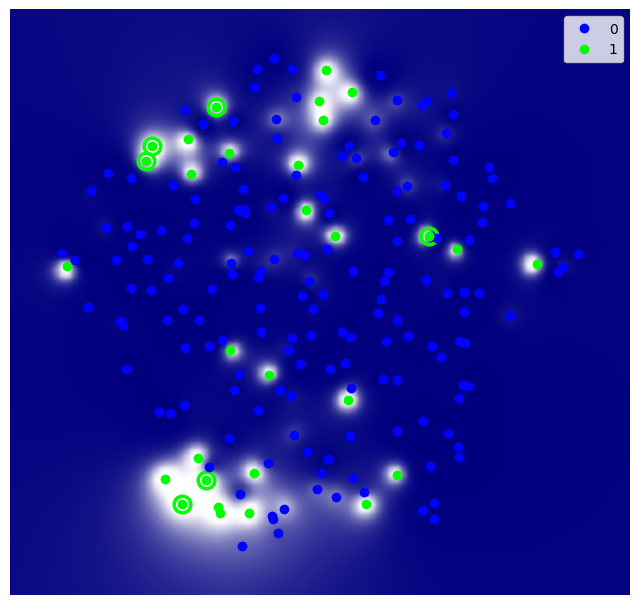

PQR 0_0_1
Embedding samples ...


/home/iroberts/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/iroberts/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Computing decision regions ...


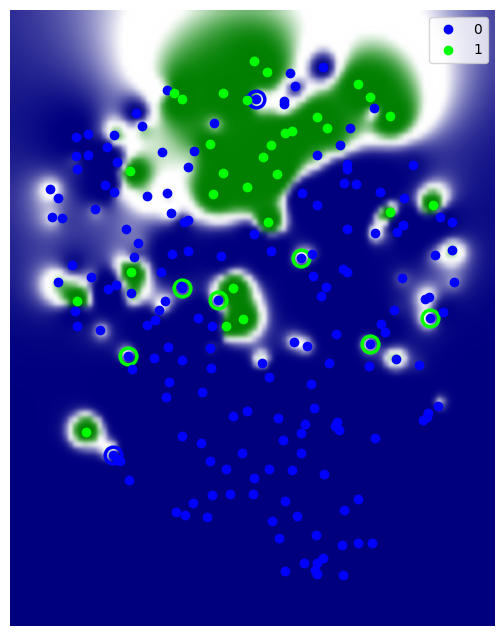

PQR 0_1_0
Embedding samples ...


/home/iroberts/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/iroberts/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Computing decision regions ...


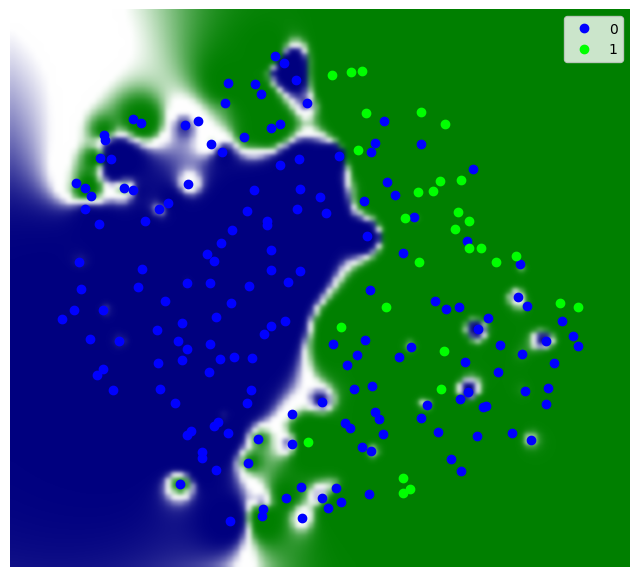

PQR 1_0_0
Embedding samples ...


/home/iroberts/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/iroberts/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Computing decision regions ...


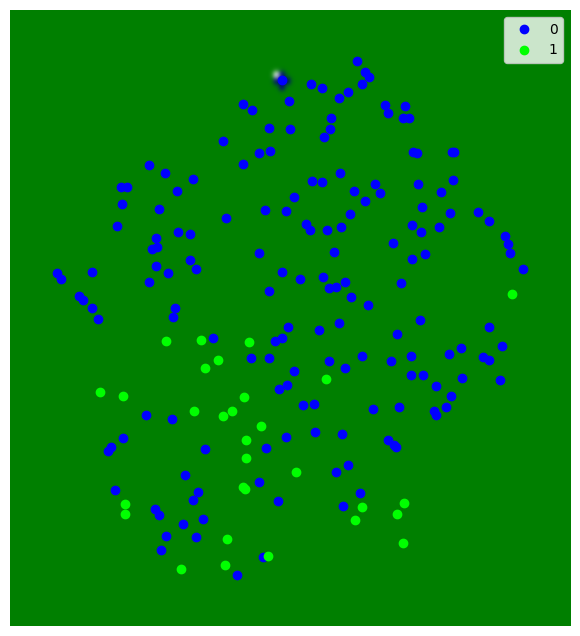

PQR 1_1_1
Embedding samples ...


/home/iroberts/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/iroberts/.local/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Computing decision regions ...


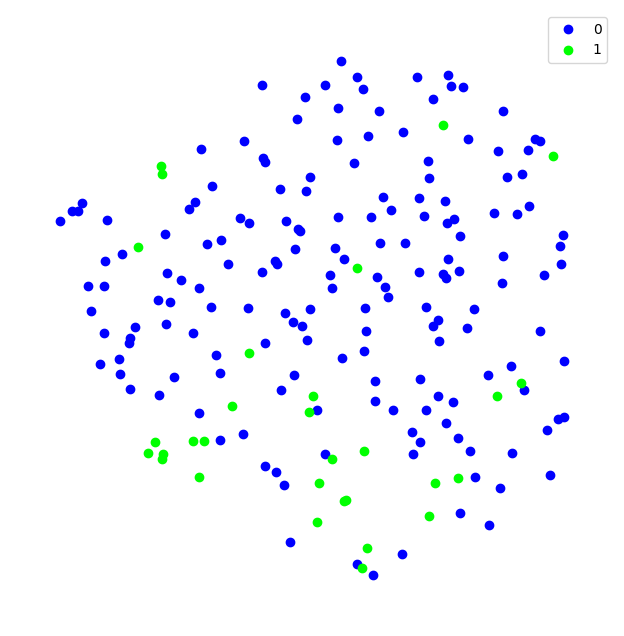

In [51]:
from deepview import DeepView
import numpy as np
import time

import os




# --- Deep View Parameters ----
batch_size = 32
max_samples = 500
data_shape = (32,)
resolution = 100
N = 10
lam = 1
cmap = 'brg'
# to make shure deepview.show is blocking,
# disable interactive mode
interactive = False
title = 'Male'



uri = "http://www.benchmark.org/family#Brother"
class_name = uri.split("#")[-1]   # → "Brother"
class_of_interest = [uri]

dir_path = f"{class_name}"

try:
    os.makedirs(dir_path, exist_ok=False)
except OSError as e:
    print(f"Error: {e}")

all_figures = []

for pqr in pqrs:
    print("PQR", pqr)
    kge_path = f"./KGs_Family_family-benchmark_rich_background_owl_{pqr}"
    
    # Load model
    pqr_model, (_, _) = load_model(path_of_experiment_folder=kge_path)

    # Get the embeddings of the model
    _, _, ind_embeddings, inds = process_family_df(get_entity_df(kge_path, pqr))

    # Get the class embeddings from the model
    class_embeddings, classes = get_class_embeddings(get_entity_df(kge_path, pqr), class_of_interest)
    
    predict_with_class = lambda h: pred_wrapper(h, class_embeddings[0], model=pqr_model, pqr=pqr,base_path=kge_path)

    gt = concept_retrieval(symbolic_kb, OWLClass(classes[0]))
    gt_set = set(gt)
    labels = np.array([1 if ind in gt_set else 0 for ind in inds])

    deepview = DeepView(
        predict_with_class, np.arange(2), max_samples, batch_size, data_shape, 
        N, lam, resolution, cmap, interactive, title, disc_dist=False
    )
    deepview.add_samples(ind_embeddings, labels)
    
    deepview.show()   # <-- if DeepView supports returning a matplotlib fig
    deepview.fig.savefig(f"{class_name}/deepview_{pqr}.png")
    # deepview.fig.savefig(f"{class_name}/deepview_{pqr}.pdf", bbox_inches="tight")


In [1]:

from deepview.evaluate import evaluate_inv_umap

pqrs = [ "0_0_0", "0_0_1", "0_1_0", "1_0_0", "1_1_1"]





for pqr in pqrs:
    print("PQR", pqr)
    kge_path = f"./KGs_Family_family-benchmark_rich_background_owl_{pqr}"
    # Load model
    pqr_model, (_, _) = load_model(path_of_experiment_folder=kge_path)

    # Get the embeddings of the model
    _, _, ind_embeddings, inds = process_family_df(get_entity_df(kge_path, pqr))

    # Get the class embeddings from the model
    class_embeddings, all_classes = get_class_embeddings(get_entity_df(kge_path, pqr), classes_of_interest)
    clifford_distance = pairwise_distances(ind_embeddings)

    train_accs = []
    test_accs = []
    precisions = []
    for i, cl in enumerate(all_classes):
        predict_with_class = lambda h: pred_wrapper(h, class_embeddings[i], model=pqr_model, pqr=pqr,base_path=kge_path)
        gt = concept_retrieval(SYMBOLIC_KB, OWLClass(all_classes[i]))
        gt_set = set(gt)
        labels = np.array([1 if ind in gt_set else 0 for ind in inds])
        results = predict_with_class(ind_embeddings)
        y_preds = np.argmax(results,axis=1)
        
        deepview = DeepView(
        predict_with_class, np.arange(2), max_samples, batch_size, data_shape, 
        N, lam, resolution, cmap, interactive, title, disc_dist=False
    )
    
        train_acc, test_acc = evaluate_inv_umap(deepview, ind_embeddings, labels)
        train_accs.append(train_acc)     
        test_accs.append(test_acc)  
    print(np.min(test_accs))
    print(np.argmin(test_accs))
    print(all_classes[np.argmin(test_accs)])
    print("Seen data accuracy_score:",np.mean(train_accs))
    print("Unseen data accuracy_score:",np.mean(test_accs))


   

2026-02-05 13:31:10.812653: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-05 13:31:10.847300: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-05 13:31:10.847329: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-05 13:31:10.848213: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-05 13:31:10.853812: I tensorflow/core/platform/cpu_feature_guar

PQR 0_0_0


NameError: name 'load_model' is not defined

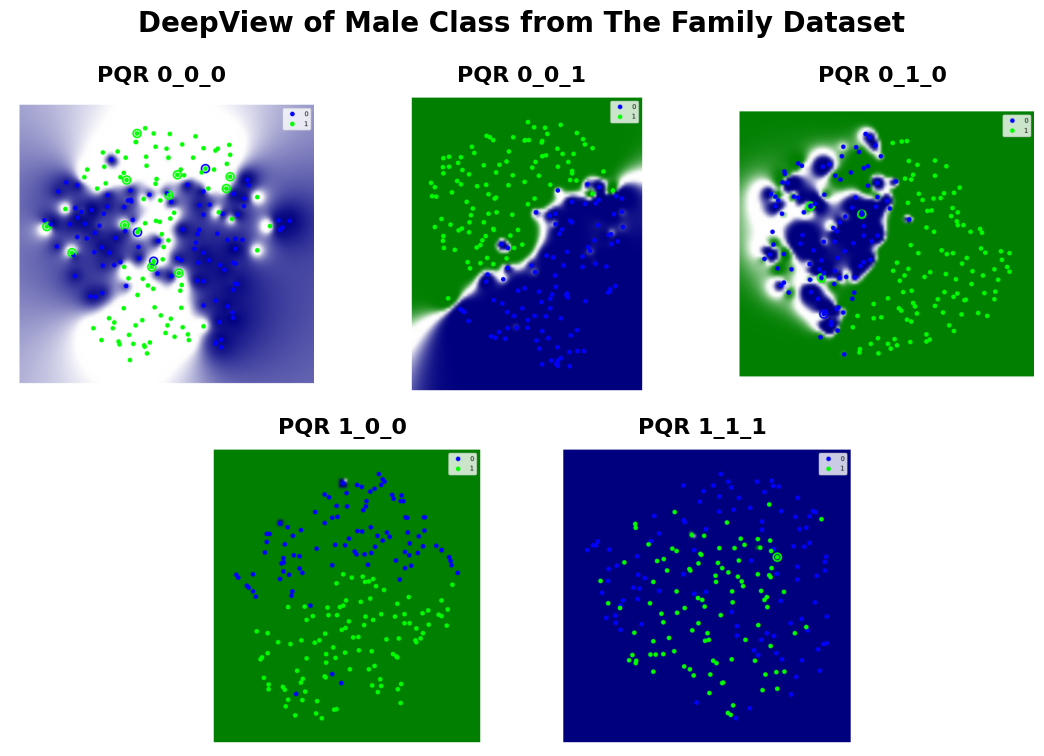

In [13]:
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

class_name = "Male"
n = len(pqrs)
rows = 2
cols = math.ceil(n / rows)  # e.g. 3 for n=5

def center_crop(img, crop_frac=0.9):
    """Crops the center portion of the image."""
    h, w = img.shape[:2]
    ch, cw = int(h * crop_frac), int(w * crop_frac)
    top = (h - ch) // 2
    left = (w - cw) // 2
    return img[top:top + ch, left:left + cw]

# --- Figure geometry in normalized figure coordinates ---
fig_w = 4 * cols   # width inches (adjust if you like)
fig_h = 4 * rows
fig = plt.figure(figsize=(fig_w, fig_h))

# margins and spacing in figure coords (0..1)
left_margin = 0.06
right_margin = 0.06
top_margin = 0.12
bottom_margin = 0.06
hspace = 0.02  # horizontal spacing between columns (figure fraction)
vspace = 0.06  # vertical spacing between rows (figure fraction)

# available width and height for axes area
avail_w = 1.0 - left_margin - right_margin
avail_h = 1.0 - top_margin - bottom_margin

# compute axis width and height for a single "grid cell"
# we divide avail_w into 'cols' cells, spacing counted as (cols - 1)*hspace * avail_w
cell_w = (avail_w - (cols - 1) * hspace) / cols
cell_h = (avail_h - (rows - 1) * vspace) / rows

# pick top row and bottom row y positions (top row is row 0)
# y for top row (row index 0)
top_row_y0 = 1.0 - top_margin - cell_h
# y for bottom row (row index 1)
bottom_row_y0 = top_row_y0 - cell_h - vspace

# plot images: first fill top row left-to-right, then bottom row
# we will build a list of axes so we can iterate easily
axes = []

# how many in top row? min(cols, n)
n_top = min(cols, n)
n_bottom = n - n_top

# place top row images in columns 0..n_top-1
for j in range(n_top):
    left = left_margin + j * (cell_w + hspace)
    ax = fig.add_axes([left, top_row_y0, cell_w, cell_h])
    axes.append(ax)

# place bottom row images centered
if n_bottom > 0:
    # fractional starting column (can be non-integer)
    start_col = (cols - n_bottom) / 2.0
    for j in range(n_bottom):
        left = left_margin + (start_col + j) * (cell_w + hspace)
        ax = fig.add_axes([left, bottom_row_y0, cell_w, cell_h])
        axes.append(ax)

# load and draw images into axes (made in the same order used above)
for ax, pqr in zip(axes, pqrs):
    img = mpimg.imread(f"{class_name}/deepview_{pqr}.png")
    img = center_crop(img, crop_frac=0.8)  # crop center 80%
    ax.imshow(img)
    ax.set_title(f"PQR {pqr}", fontsize=16, fontweight='bold')
    ax.axis("off")

# add suptitle
fig.suptitle(f"DeepView of {class_name} Class from The Family Dataset",
             fontsize=20, fontweight='bold', y=0.98)


plt.savefig(f"{class_name}/for_paper.pdf", bbox_inches="tight")
plt.show()

